In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [3]:
# df = pd.read_csv("train.csv").drop(columns=['GarageQual','FireplaceQu','SalePrice'])

In [4]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [5]:
df.isnull().count()

FireplaceQu    1460
GarageQual     1460
SalePrice      1460
dtype: int64

In [6]:
df['GarageQual'].value_counts()

GarageQual
TA    1311
Fa      48
Gd      14
Ex       3
Po       3
Name: count, dtype: int64

array([<Axes: title={'center': 'count'}, xlabel='GarageQual'>],
      dtype=object)

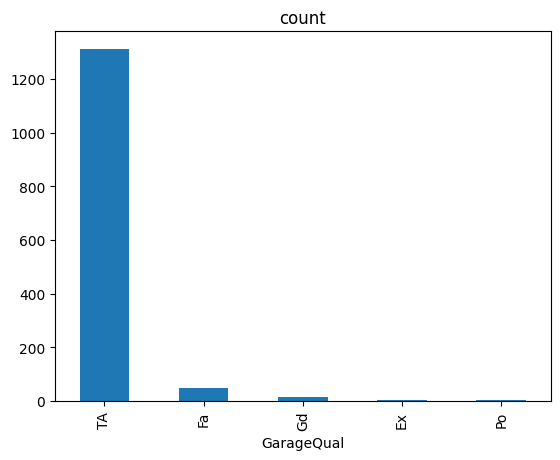

In [7]:
# df['GarageQual'].value_counts().plot(kind='bar')
df['GarageQual'].value_counts().plot(kind='bar',subplots=True)

In [8]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: str

Text(0.5, 1.0, 'GarageQual')

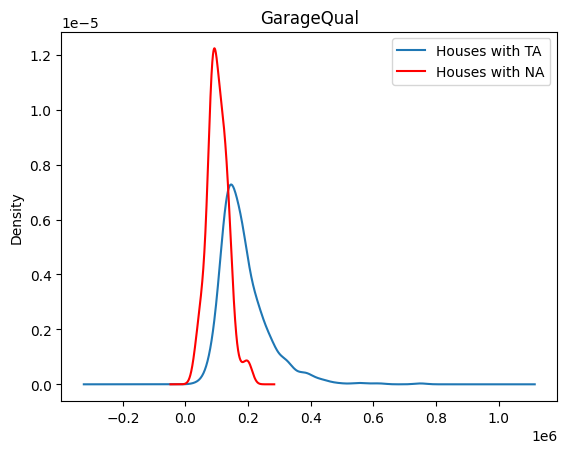

In [9]:
fig = plt.figure()#Creates an empty matplotlib figure.
ax = fig.add_subplot(111)#2. Add Graph Area (Axes)
# Creates one subplot.

# 111 means:

# 1 row
# 1 column
# 1st graph

# So you are creating a single graph area.

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde', ax=ax)#3. Plot KDE for Houses with GarageQual = TA
# df['GarageQual']=='TA'=Selects rows where Garage Quality is "TA".
# ['SalePrice']=Get SalePrice Column Only takes sale prices.
# KDE = smooth probability distribution curve.
# It shows:
# where most house prices are concentrated
# price distribution shape
# ax=ax
# Draws plot on the same graph.

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')
# 4. Plot KDE for Missing GarageQual
# Selects houses where GarageQual is missing.
# color='red' ->Now second distribution curve is red.

lines, labels = ax.get_legend_handles_labels()#Gets plotted line objects and labels.
labels = ['Houses with TA', 'Houses with NA']#6. Rename Labels
ax.legend(lines, labels, loc='best')#7. Add Legend
# loc='best'
# → matplotlib automatically chooses best position.

plt.title('GarageQual')#8. Add Title
# If both curves are similar:
# → Missing values may behave like TA houses.

# If very different:
# → Missing values carry important information.
# Important Concept

# This is commonly used in:

# Missing value analysis
# Feature engineering
# Data preprocessing in ML

# Especially before:

# imputation
# encoding
# model training

In [28]:
temp = df[df['GarageQual']=='TA']['SalePrice']
print(temp)

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1311, dtype: int64


In [ ]:
df['GarageQual'].fillna('TA', inplace=True)
# 3. inplace=True
# This updates the original dataframe directly.

GarageQual
TA    1311
Fa      48
Gd      14
Ex       3
Po       3
Name: count, dtype: int64


<Axes: xlabel='GarageQual'>

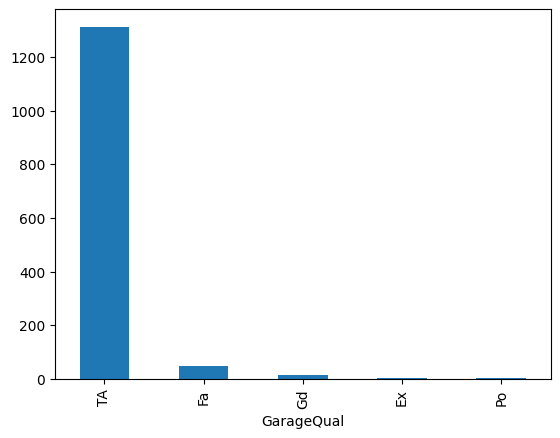

In [29]:
print(df['GarageQual'].value_counts())
df['GarageQual'].value_counts().plot(kind='bar')#This line creates a bar chart showing how many times each category appears in the GarageQual column.

Text(0.5, 1.0, 'GarageQual')

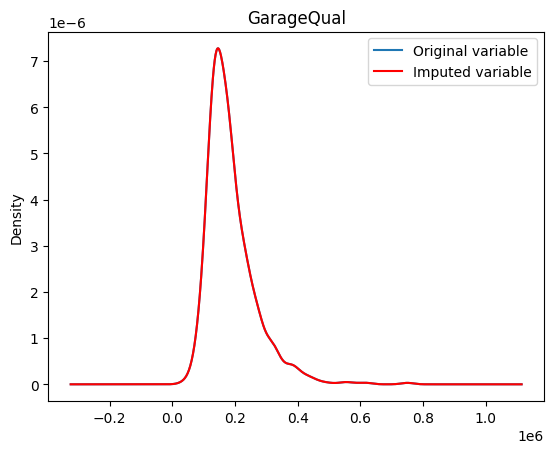

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)


temp.plot(kind='kde', ax=ax)
# df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax, color='red')
# distribution of the variable after imputation
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

# add title
plt.title('GarageQual')

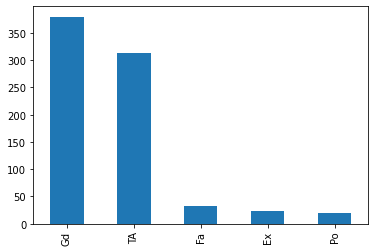

In [49]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [50]:
df['FireplaceQu'].mode()

0    Gd
dtype: object

Text(0.5, 1.0, 'FireplaceQu')

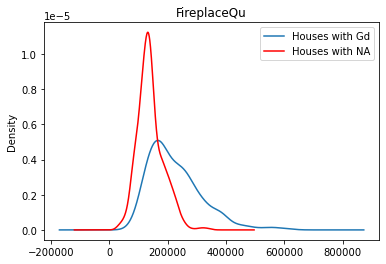

In [51]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu')

In [52]:
temp = df[df['FireplaceQu']=='Gd']['SalePrice']

In [53]:
df['FireplaceQu'].fillna('Gd', inplace=True)

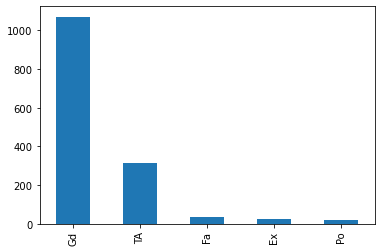

In [54]:
df['FireplaceQu'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'FireplaceQu')

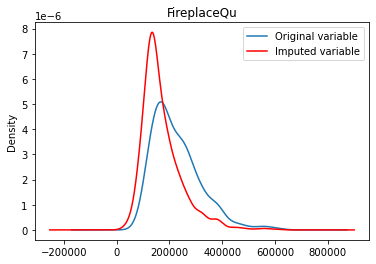

In [55]:
fig = plt.figure()
ax = fig.add_subplot(111)


temp.plot(kind='kde', ax=ax)

# distribution of the variable after imputation
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

# add title
plt.title('FireplaceQu')

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)

In [35]:
from sklearn.impute import SimpleImputer

In [37]:
imputer = SimpleImputer(strategy='most_frequent')

In [39]:
X_train = imputer.fit_transform(X_train)#✅ Training data is used to learn.
# ❌ Test data should never teach the model.
# Otherwise:
# data leakage happens
# model accuracy becomes fake.
# A. fit()
# Learns missing value replacement from training data.
# Example
# mean_age = 25
# The imputer calculates:
# mean
# median
# most frequent value
# (depending on strategy)
# ONLY from training data.
# X_test = imputer.transform(X_train)
# B. transform()
# Actually replaces missing values.
# Example:
# NaN → 25


# Important Interview Concept
# Why fit only on training data?
# Because:
# test data should remain unseen
# otherwise model indirectly learns test information.
# This is called:
# Data Leakage
# and it is a major ML mistake.

In [40]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)